# RFID Clone Detection — Evidence Ablation Study

**Research question:** *Which source of security evidence helps detect RFID clones?*

This notebook is deliberately **not** designed to answer whether Random Forest or SVM is better.

It implements:

- **E1 — Protocol Only**
- **E2 — Behavioral Only**
- **E3 — Protocol + Behavioral**
- Random Forest and SVM are used as detectors for **E2/E3**, not ranked as the scientific question.
- Session/tag-aware Train–Validation–Test splitting.
- Group-aware cross-validation on the training set.
- No event-level random splitting.
- Final output focuses on the contribution of evidence sources.

## Data mapping used by default

- **S1 = Genuine / Real**
- **S2 = Genuine / Real protocol experiment**
- **S3 = Clone / Fake**
- **S4 = Replay experiment**
- **S5 = Replay success-rate summary**

> The S2 label is configurable below. The notebook will stop if this mapping is not explicitly confirmed.

The notebook keeps S4/S5 as **supporting replay evidence** rather than silently mixing them into the primary Real-vs-Clone classifier, because they contain 36 sessions while S1/S2/S3 contain 108 sessions and represent a distinct experiment.


In [1]:
# ============================================================
# CELL 1 — Install / imports
# ============================================================

!pip -q install openpyxl

import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Environment ready.")


Environment ready.


## CELL 2 — Upload the files

Upload these files:

- `meta_sessions_S1_clean.xlsx`
- `meta_sessions_S2.csv`
- `s2_collisions_summary.csv`
- `s3_clone_collisions_summary_clean.xlsx`
- `s3_summary_counts.csv`
- `s4_replay_summary.csv`
- `s4_merge_summary.json`
- `s5_success_rates_per_session.csv`

The notebook only requires S1, S2 and S3 for the primary E1/E2/E3 experiment. S4/S5 are retained as a separate replay-support analysis.


In [2]:
uploaded = files.upload()

print("\nUploaded:")
for f in uploaded:
    print(" -", f)


Saving meta_sessions_S1_clean.xlsx to meta_sessions_S1_clean.xlsx
Saving meta_sessions_S2.csv to meta_sessions_S2.csv
Saving s2_collisions_summary.csv to s2_collisions_summary.csv
Saving s3_clone_collisions_summary_clean.xlsx to s3_clone_collisions_summary_clean.xlsx
Saving s3_summary_counts.csv to s3_summary_counts.csv
Saving s4_merge_summary.json to s4_merge_summary.json
Saving s4_replay_summary.csv to s4_replay_summary.csv
Saving s5_success_rates_per_session.csv to s5_success_rates_per_session.csv

Uploaded:
 - meta_sessions_S1_clean.xlsx
 - meta_sessions_S2.csv
 - s2_collisions_summary.csv
 - s3_clone_collisions_summary_clean.xlsx
 - s3_summary_counts.csv
 - s4_merge_summary.json
 - s4_replay_summary.csv
 - s5_success_rates_per_session.csv


In [3]:
# ============================================================
# CELL 3 — UPLOAD DATA FILES
# ============================================================

from google.colab import files
import os

print("Hãy chọn TOÀN BỘ các file dữ liệu của nhóm.")
print("Sau khi chọn xong, Colab sẽ lưu chúng vào /content/")

uploaded = files.upload()

print("\nCác file đã upload:")
for f in uploaded.keys():
    print("  ✓", f)

print("\nFiles hiện có trong /content:")
for f in os.listdir("/content"):
    if f.lower().endswith((".csv", ".xlsx", ".json")):
        print("  -", f)

Hãy chọn TOÀN BỘ các file dữ liệu của nhóm.
Sau khi chọn xong, Colab sẽ lưu chúng vào /content/
Saving meta_sessions_S1_clean.xlsx to meta_sessions_S1_clean.xlsx
Saving meta_sessions_S2.csv to meta_sessions_S2.csv
Saving s2_collisions_summary.csv to s2_collisions_summary.csv
Saving s3_clone_collisions_summary_clean.xlsx to s3_clone_collisions_summary_clean.xlsx
Saving s3_summary_counts.csv to s3_summary_counts.csv
Saving s4_merge_summary.json to s4_merge_summary.json
Saving s4_replay_summary.csv to s4_replay_summary.csv
Saving s5_success_rates_per_session.csv to s5_success_rates_per_session.csv

Các file đã upload:
  ✓ meta_sessions_S1_clean.xlsx
  ✓ meta_sessions_S2.csv
  ✓ s2_collisions_summary.csv
  ✓ s3_clone_collisions_summary_clean.xlsx
  ✓ s3_summary_counts.csv
  ✓ s4_merge_summary.json
  ✓ s4_replay_summary.csv
  ✓ s5_success_rates_per_session.csv

Files hiện có trong /content:
  - rfid_evidence_summary.csv
  - s4_merge_summary.json
  - rq3_table_4y.csv
  - s3_clone_collisions_

In [4]:
# ============================================================
# CELL 4 — CHECK FILES
# ============================================================

FILES = {
    "S1": "meta_sessions_S1_clean.xlsx",
    "S2_META": "meta_sessions_S2.csv",
    "S2_COLL": "s2_collisions_summary.csv",
    "S3": "s3_clone_collisions_summary_clean.xlsx",
    "S3_COUNTS": "s3_summary_counts.csv",
    "S4": "s4_replay_summary.csv",
    "S4_JSON": "s4_merge_summary.json",
    "S5": "s5_success_rates_per_session.csv",
}

missing = [
    filename
    for filename in FILES.values()
    if not os.path.exists(filename)
]

if missing:
    print("❌ Vẫn còn thiếu:")
    for f in missing:
        print("   -", f)
else:
    print("✅ Tất cả file cần thiết đã có trong Colab.")

✅ Tất cả file cần thiết đã có trong Colab.


In [5]:
# ============================================================
# CELL 4 — Explicit experimental mapping
# ============================================================

LABELS = {
    "S1": 0,   # Real
    "S2": 0,   # Real protocol experiment
    "S3": 1,   # Clone/Fake
}

LABEL_NAMES = {
    0: "Real",
    1: "Clone"
}

# IMPORTANT:
# If your experimental documentation says S2 is NOT a genuine/real
# protocol experiment, change this mapping before continuing.
S2_IS_REAL_PROTOCOL_EXPERIMENT = True

assert S2_IS_REAL_PROTOCOL_EXPERIMENT, (
    "Confirm the S2 label before running the primary experiment."
)

print("S1 -> Real")
print("S2 -> Real protocol evidence")
print("S3 -> Clone")


S1 -> Real
S2 -> Real protocol evidence
S3 -> Clone


In [6]:
# ============================================================
# CELL 5 — Load data
# ============================================================

s1 = pd.read_excel(FILES["S1"])
s2_meta = pd.read_csv(FILES["S2_META"])
s2_coll = pd.read_csv(FILES["S2_COLL"])
s3 = pd.read_excel(FILES["S3"])
s3_counts = pd.read_csv(FILES["S3_COUNTS"])
s4 = pd.read_csv(FILES["S4"])
s5 = pd.read_csv(FILES["S5"])

with open(FILES["S4_JSON"], "r") as f:
    s4_json = json.load(f)

datasets = {
    "S1": s1,
    "S2 metadata": s2_meta,
    "S2 collisions": s2_coll,
    "S3": s3,
    "S3 counts": s3_counts,
    "S4 replay": s4,
    "S5 success": s5,
}

for name, df in datasets.items():
    print(f"{name:18s}: shape={df.shape}")


S1                : shape=(108, 8)
S2 metadata       : shape=(18, 7)
S2 collisions     : shape=(31664, 5)
S3                : shape=(7100, 6)
S3 counts         : shape=(24, 4)
S4 replay         : shape=(21062, 3)
S5 success        : shape=(36, 4)


In [7]:
# ============================================================
# CELL 6 — Data audit
# ============================================================

print("S1 columns:", s1.columns.tolist())
print("S2 collision columns:", s2_coll.columns.tolist())
print("S3 columns:", s3.columns.tolist())

print("\nUnique sessions:")
print("S1:", s1["session_id"].nunique())
print("S2:", s2_coll["session_id"].nunique())
print("S3:", s3["session_id"].nunique())
print("S4:", s4["session_id"].nunique())
print("S5:", s5["session_id"].nunique())

print("\nS2 collision events:", len(s2_coll))
print("S3 collision events:", len(s3))
print("S4 replay events:", len(s4))


S1 columns: ['session_id', 'total_reads', 'success_reads', 'success_rate', 'tag_local_id', 'distance_cm', 'orientation_deg', 'repetitions']
S2 collision columns: ['session_id', 'uid', 'tA', 'tB', 'dt']
S3 columns: ['session_id', 'uid_hash', 'uid_plain_local', 't_reader_A', 't_reader_B', 'delta_ms']

Unique sessions:
S1: 108
S2: 108
S3: 108
S4: 36
S5: 36

S2 collision events: 31664
S3 collision events: 7100
S4 replay events: 21062


# Part A — Construct session-level evidence

**Rule:** the ML unit is a session. Raw collision/replay events are aggregated first.

This prevents the same session from being split across train and test.


In [8]:
# ============================================================
# CELL 7 — S1 behavioral session features
# ============================================================

real_behavior = s1.copy()

real_behavior["read_count"] = real_behavior["total_reads"]

real_behavior["read_success_gap"] = (
    real_behavior["total_reads"] - real_behavior["success_reads"]
)

real_behavior["read_efficiency"] = (
    real_behavior["success_reads"] /
    real_behavior["total_reads"].replace(0, np.nan)
)

real_behavior["label"] = 0
real_behavior["source"] = "S1"

REAL_BEHAVIOR_FEATURES = [
    "read_count",
    "success_rate",
    "distance_cm",
    "orientation_deg",
    "repetitions",
    "read_success_gap",
    "read_efficiency",
]

display(real_behavior[
    ["session_id", "tag_local_id"] + REAL_BEHAVIOR_FEATURES + ["label"]
].head())


,session_id,tag_local_id,read_count,success_rate,distance_cm,orientation_deg,repetitions,read_success_gap,read_efficiency,label
0,S20251104_S1_TAG01_d1_o0_run1,TAG01,154,98.05,1,0,150,3,0.980519,0
1,S20251104_S1_TAG01_d1_o45_run1,TAG01,150,92.00,1,45,150,12,0.920000,0
2,S20251104_S1_TAG01_d1_o90_run1,TAG01,150,100.00,1,90,150,0,1.000000,0
3,S20251104_S1_TAG01_d3_o0_run1,TAG01,150,100.00,3,0,150,0,1.000000,0
4,S20251104_S1_TAG01_d3_o45_run1,TAG01,150,92.67,3,45,150,11,0.926667,0


In [9]:
# ============================================================
# CELL 8 — S2 protocol session features
# ============================================================

def protocol_features_from_collision_events(df, session_col, dt_col):
    g = df.groupby(session_col)[dt_col]

    out = g.agg(
        collision_count="count",
        dt_mean="mean",
        dt_std="std",
        dt_median="median",
        dt_min="min",
        dt_max="max",
        dt_abs_mean=lambda x: np.abs(x).mean(),
        dt_abs_median=lambda x: np.abs(x).median(),
    ).reset_index()

    # Robust protocol indicators
    tmp = df[[session_col, dt_col]].copy()

    by_session = tmp.groupby(session_col)[dt_col]

    small_10 = by_session.apply(lambda x: (np.abs(x) <= 0.010).mean())
    small_50 = by_session.apply(lambda x: (np.abs(x) <= 0.050).mean())
    pos_ratio = by_session.apply(lambda x: (x > 0).mean())
    neg_ratio = by_session.apply(lambda x: (x < 0).mean())
    zero_ratio = by_session.apply(lambda x: (x == 0).mean())

    extra = pd.DataFrame({
        session_col: small_10.index,
        "small_dt_10ms_ratio": small_10.values,
        "small_dt_50ms_ratio": small_50.values,
        "positive_dt_ratio": pos_ratio.values,
        "negative_dt_ratio": neg_ratio.values,
        "zero_dt_ratio": zero_ratio.values,
    })

    return out.merge(extra, on=session_col, how="left")


s2_protocol = protocol_features_from_collision_events(
    s2_coll,
    "session_id",
    "dt"
)

s2_protocol["label"] = 0
s2_protocol["source"] = "S2"

display(s2_protocol.head())


,session_id,collision_count,dt_mean,dt_std,dt_median,dt_min,dt_max,dt_abs_mean,dt_abs_median,small_dt_10ms_ratio,small_dt_50ms_ratio,positive_dt_ratio,negative_dt_ratio,zero_dt_ratio,label,source
0,S20251109_S2_TAG01_d1_o0_run1,288,-0.031977,0.201819,-0.001739,-0.739832,0.584224,0.148619,0.099293,0.100694,0.375000,0.496528,0.503472,0.0,0,S2
1,S20251109_S2_TAG01_d1_o45_run1,290,-0.016742,0.201916,-0.000249,-0.499547,0.515503,0.149435,0.114136,0.113793,0.368966,0.500000,0.500000,0.0,0,S2
2,S20251109_S2_TAG01_d1_o90_run1,291,-0.016099,0.185532,-0.001064,-0.508431,0.368128,0.139578,0.095347,0.106529,0.350515,0.494845,0.505155,0.0,0,S2
3,S20251109_S2_TAG01_d3_o0_run1,292,-0.017212,0.193586,0.000268,-0.471586,0.525807,0.146371,0.114350,0.082192,0.318493,0.500000,0.500000,0.0,0,S2
4,S20251109_S2_TAG01_d3_o45_run1,293,-0.018865,0.182769,0.001178,-0.478266,0.383995,0.139056,0.106475,0.064846,0.351536,0.501706,0.498294,0.0,0,S2


In [10]:
# ============================================================
# CELL 9 — S3 protocol + behavioral session features
# ============================================================

s3_work = s3.copy()

s3_work["dt_sec"] = s3_work["delta_ms"] / 1000.0

s3_protocol = protocol_features_from_collision_events(
    s3_work,
    "session_id",
    "dt_sec"
)

# UID diversity is protocol evidence, but raw UID itself is NEVER used.
uid_stats = (
    s3.groupby("session_id")["uid_hash"]
       .nunique()
       .rename("uid_count")
       .reset_index()
)

s3_protocol = s3_protocol.merge(
    uid_stats,
    on="session_id",
    how="left"
)

# Session-level behavioral summaries available from the same S3 experiment.
s3_behavior = (
    s3.groupby("session_id")
      .agg(
          read_count=("uid_hash", "count"),
          reader_a_time_count=("t_reader_A", "count"),
          reader_b_time_count=("t_reader_B", "count"),
      )
      .reset_index()
)

s3_behavior["reader_balance"] = (
    s3_behavior["reader_a_time_count"] /
    s3_behavior[["reader_a_time_count", "reader_b_time_count"]]
    .sum(axis=1)
)

s3_protocol["label"] = 1
s3_protocol["source"] = "S3"

s3_behavior["label"] = 1
s3_behavior["source"] = "S3"

display(s3_protocol.head())
display(s3_behavior.head())


,session_id,collision_count,dt_mean,dt_std,dt_median,dt_min,dt_max,dt_abs_mean,dt_abs_median,small_dt_10ms_ratio,small_dt_50ms_ratio,positive_dt_ratio,negative_dt_ratio,zero_dt_ratio,uid_count,label,source
0,S20251110_S3_P10_run1,72,0.002694,0.001580,0.003,0.0,0.005,0.002694,0.003,1.0,1.0,0.888889,0.0,0.111111,1,1,S3
1,S20251110_S3_P10_run2,70,0.002271,0.001532,0.002,0.0,0.005,0.002271,0.002,1.0,1.0,0.857143,0.0,0.142857,1,1,S3
2,S20251110_S3_P10_run3,59,0.002373,0.001751,0.002,0.0,0.005,0.002373,0.002,1.0,1.0,0.864407,0.0,0.135593,1,1,S3
3,S20251110_S3_P11_run1,63,0.002365,0.001548,0.002,0.0,0.005,0.002365,0.002,1.0,1.0,0.984127,0.0,0.015873,1,1,S3
4,S20251110_S3_P11_run2,66,0.002621,0.001486,0.003,0.0,0.005,0.002621,0.003,1.0,1.0,0.954545,0.0,0.045455,1,1,S3


,session_id,read_count,reader_a_time_count,reader_b_time_count,reader_balance,label,source
0,S20251110_S3_P10_run1,72,72,72,0.5,1,S3
1,S20251110_S3_P10_run2,70,70,70,0.5,1,S3
2,S20251110_S3_P10_run3,59,59,59,0.5,1,S3
3,S20251110_S3_P11_run1,63,63,63,0.5,1,S3
4,S20251110_S3_P11_run2,66,66,66,0.5,1,S3


## Important evidence rule

We **do not** use:

- `session_id`
- `uid`
- `uid_hash`
- `uid_plain_local`
- file name
- source name

as ML features.

Those are identifiers/provenance and would allow shortcut learning.

We also do not replace missing Real protocol measurements with zero unless the experimental protocol explicitly defines zero as an observed value.

For the primary E1/E2/E3 experiment, S2 provides the genuine-tag protocol evidence and S3 provides clone protocol evidence; S1 provides the genuine behavioral measurements and S3 provides the clone session-level read behavior.


In [11]:
# ============================================================
# CELL 10 — Build the primary session-level dataset
# ============================================================

# ----- Protocol evidence -----
PROTOCOL_FEATURES = [
    "collision_count",
    "dt_mean",
    "dt_std",
    "dt_median",
    "dt_min",
    "dt_max",
    "dt_abs_mean",
    "dt_abs_median",
    "small_dt_10ms_ratio",
    "small_dt_50ms_ratio",
    "positive_dt_ratio",
    "negative_dt_ratio",
    "zero_dt_ratio",
]

# S3 protocol features are generated in seconds.
# S2 dt is already in seconds.
protocol_real = s2_protocol[
    ["session_id"] + PROTOCOL_FEATURES + ["label"]
].copy()

protocol_clone = s3_protocol[
    ["session_id"] + PROTOCOL_FEATURES + ["label"]
].copy()

protocol_data = pd.concat(
    [protocol_real, protocol_clone],
    ignore_index=True
)

# ----- Common behavioral evidence -----
# The strict common feature available for both S1 and S3 is read_count.
# Additional S1-only physical variables are retained for descriptive analysis,
# but are NOT silently imputed into S3.
BEHAVIOR_FEATURES = [
    "read_count",
]

behavior_real = real_behavior[
    ["session_id", "read_count", "label"]
].copy()

behavior_clone = s3_behavior[
    ["session_id", "read_count", "label"]
].copy()

behavior_data = pd.concat(
    [behavior_real, behavior_clone],
    ignore_index=True
)

# ----- Merge by a synthetic experiment-independent sample index -----
# We do NOT merge S1 and S2 by session_id because they have different session
# naming schemes. They are separate repeated sessions for the same evidence class.
# Each row remains one observed session.

# Add group identifier: TAG is the higher-level repeated unit where available.
def extract_tag(x):
    m = re.search(r"(TAG\d+)", str(x))
    return m.group(1) if m else str(x)

protocol_data["tag_group"] = protocol_data["session_id"].map(extract_tag)
behavior_data["tag_group"] = behavior_data["session_id"].map(extract_tag)

print("Protocol samples:", len(protocol_data))
print("Behavior samples:", len(behavior_data))
print("\nProtocol labels:")
print(protocol_data["label"].value_counts())
print("\nBehavior labels:")
print(behavior_data["label"].value_counts())


Protocol samples: 216
Behavior samples: 216

Protocol labels:
label
0    108
1    108
Name: count, dtype: int64

Behavior labels:
label
0    108
1    108
Name: count, dtype: int64


# Part B — E1 / E2 / E3 design

### E1 — Protocol Only
Uses only protocol/temporal evidence.

### E2 — Behavioral Only
Uses only the strict common behavioral feature `read_count`.

### E3 — Protocol + Behavioral
Uses the E1 protocol features plus `read_count`.

**Scientific question:** whether the added evidence family changes clone-detection capability.

RF and SVM are detector implementations inside E2/E3. Their individual scores are not interpreted as a "winner".


In [12]:
# ============================================================
# CELL 11 — Build E1 / E2 / E3 datasets
# ============================================================

# Match protocol and behavioral samples by label and tag/run position.
# We do not merge different experiments by their literal session IDs.
# Instead, we create an experiment-local sample key and keep tag as the group.

def make_sample_index(df):
    out = df.copy()
    out["tag_group"] = out["session_id"].map(extract_tag)
    out["within_tag_order"] = out.groupby("tag_group").cumcount()
    out["sample_key"] = (
        out["tag_group"].astype(str)
        + "__"
        + out["within_tag_order"].astype(str)
    )
    return out

protocol_data = make_sample_index(protocol_data)
behavior_data = make_sample_index(behavior_data)

# Keep only matching sample counts per tag and label.
# This prevents arbitrary duplication.
common_keys = sorted(
    set(protocol_data["sample_key"])
    & set(behavior_data["sample_key"])
)

p = protocol_data[protocol_data["sample_key"].isin(common_keys)].copy()
b = behavior_data[behavior_data["sample_key"].isin(common_keys)].copy()

# Validate labels agree for each key.
check = p[["sample_key", "label"]].merge(
    b[["sample_key", "label"]],
    on="sample_key",
    suffixes=("_protocol", "_behavior")
)

assert (check["label_protocol"] == check["label_behavior"]).all(),     "Protocol and behavioral labels do not agree."

# Final unified table.
evidence_data = p[
    ["sample_key", "tag_group", "label"] + PROTOCOL_FEATURES
].merge(
    b[
        ["sample_key", "read_count"]
    ],
    on="sample_key",
    how="inner"
)

print("Unified samples:", evidence_data.shape)
print(evidence_data["label"].value_counts())
display(evidence_data.head())


Unified samples: (216, 17)
label
0    108
1    108
Name: count, dtype: int64


,sample_key,tag_group,label,collision_count,dt_mean,dt_std,dt_median,dt_min,dt_max,dt_abs_mean,dt_abs_median,small_dt_10ms_ratio,small_dt_50ms_ratio,positive_dt_ratio,negative_dt_ratio,zero_dt_ratio,read_count
0,TAG01__0,TAG01,0,288,-0.031977,0.201819,-0.001739,-0.739832,0.584224,0.148619,0.099293,0.100694,0.375000,0.496528,0.503472,0.0,154
1,TAG01__1,TAG01,0,290,-0.016742,0.201916,-0.000249,-0.499547,0.515503,0.149435,0.114136,0.113793,0.368966,0.500000,0.500000,0.0,150
2,TAG01__2,TAG01,0,291,-0.016099,0.185532,-0.001064,-0.508431,0.368128,0.139578,0.095347,0.106529,0.350515,0.494845,0.505155,0.0,150
3,TAG01__3,TAG01,0,292,-0.017212,0.193586,0.000268,-0.471586,0.525807,0.146371,0.114350,0.082192,0.318493,0.500000,0.500000,0.0,150
4,TAG01__4,TAG01,0,293,-0.018865,0.182769,0.001178,-0.478266,0.383995,0.139056,0.106475,0.064846,0.351536,0.501706,0.498294,0.0,150


In [13]:
# ============================================================
# CELL 12 — Leakage checks
# ============================================================

# 1) No identifier used as a feature.
FORBIDDEN = {
    "session_id", "uid", "uid_hash", "uid_plain_local",
    "sample_key", "tag_group", "source", "label"
}

assert not (FORBIDDEN & set(PROTOCOL_FEATURES + BEHAVIOR_FEATURES))

# 2) One row = one session-level observation.
assert evidence_data["sample_key"].is_unique

# 3) Group is tag-level, so all repeated runs of a tag stay together.
print("Unique tags/groups:", evidence_data["tag_group"].nunique())
print("Rows:", len(evidence_data))

print("\nRows per tag:")
display(evidence_data.groupby(["label", "tag_group"]).size().describe())

print("\nNo forbidden identifiers are ML features.")


Unique tags/groups: 120
Rows: 216

Rows per tag:


count    120.000000
mean       1.800000
std        2.410063
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        9.000000
dtype: float64


No forbidden identifiers are ML features.


# Part C — Group-aware Train / Validation / Test

The primary grouping unit is **tag**.

This is intentionally stricter than event-level splitting:

- all sessions belonging to a tag remain in the same partition;
- raw S2/S3 events are never split across partitions;
- model selection/CV happens only inside the training portion;
- the held-out test set is touched once for final evaluation.

This is designed to reduce identity leakage from repeated runs of the same physical tag.


In [14]:
# ============================================================
# CELL 13 — Group-aware split
# ============================================================

def group_train_val_test_split(df, feature_cols, test_size=0.20, val_size=0.20, seed=42):
    X = df[feature_cols].copy()
    y = df["label"].copy()
    groups = df["tag_group"].copy()

    # First: held-out test
    gss_test = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=seed
    )

    trainval_idx, test_idx = next(
        gss_test.split(X, y, groups)
    )

    X_trainval = X.iloc[trainval_idx].reset_index(drop=True)
    y_trainval = y.iloc[trainval_idx].reset_index(drop=True)
    g_trainval = groups.iloc[trainval_idx].reset_index(drop=True)

    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)
    g_test = groups.iloc[test_idx].reset_index(drop=True)

    # Second: validation from train+validation
    relative_val = val_size / (1 - test_size)

    gss_val = GroupShuffleSplit(
        n_splits=1,
        test_size=relative_val,
        random_state=seed + 1
    )

    train_idx, val_idx = next(
        gss_val.split(
            X_trainval,
            y_trainval,
            g_trainval
        )
    )

    X_train = X_trainval.iloc[train_idx].reset_index(drop=True)
    y_train = y_trainval.iloc[train_idx].reset_index(drop=True)
    g_train = g_trainval.iloc[train_idx].reset_index(drop=True)

    X_val = X_trainval.iloc[val_idx].reset_index(drop=True)
    y_val = y_trainval.iloc[val_idx].reset_index(drop=True)
    g_val = g_trainval.iloc[val_idx].reset_index(drop=True)

    return {
        "X_train": X_train, "y_train": y_train, "g_train": g_train,
        "X_val": X_val, "y_val": y_val, "g_val": g_val,
        "X_test": X_test, "y_test": y_test, "g_test": g_test,
    }


def print_split_info(split, name):
    print(f"\n{name}")
    print(" rows :", len(split["X_" + name.lower()]) if "X_" + name.lower() in split else "")


In [15]:
# ============================================================
# CELL 14 — Define evidence sets
# ============================================================

E1_FEATURES = PROTOCOL_FEATURES
E2_FEATURES = ["read_count"]
E3_FEATURES = PROTOCOL_FEATURES + ["read_count"]

print("E1:", E1_FEATURES)
print("\nE2:", E2_FEATURES)
print("\nE3:", E3_FEATURES)


E1: ['collision_count', 'dt_mean', 'dt_std', 'dt_median', 'dt_min', 'dt_max', 'dt_abs_mean', 'dt_abs_median', 'small_dt_10ms_ratio', 'small_dt_50ms_ratio', 'positive_dt_ratio', 'negative_dt_ratio', 'zero_dt_ratio']

E2: ['read_count']

E3: ['collision_count', 'dt_mean', 'dt_std', 'dt_median', 'dt_min', 'dt_max', 'dt_abs_mean', 'dt_abs_median', 'small_dt_10ms_ratio', 'small_dt_50ms_ratio', 'positive_dt_ratio', 'negative_dt_ratio', 'zero_dt_ratio', 'read_count']


In [16]:
# ============================================================
# CELL 15 — Evaluation helpers
# ============================================================

def metric_row(evidence, model, y_true, y_pred):
    return {
        "Evidence": evidence,
        "Detector": model,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


def print_report(evidence, model, y_true, y_pred):
    print(f"\n===== {evidence} / {model} =====")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Real", "Clone"],
        zero_division=0
    ))


# Part D — E1: Protocol Only

E1 is deliberately evaluated as a **protocol evidence experiment**.

It does not compare RF vs SVM. The goal is to establish how much discrimination is available from the protocol/temporal evidence family itself.

For a compact primary result, we use a transparent protocol score based on the training set. A threshold is learned from training only and applied to validation/test.

The direction is learned from the training data rather than assumed.


In [17]:
# ============================================================
# CELL 16 — E1 transparent protocol detector
# ============================================================

def fit_univariate_protocol_detector(X_train, y_train):
    # Choose the single protocol feature with the strongest training-set
    # separation using a simple standardized mean difference.
    scores = {}

    for col in X_train.columns:
        a = X_train.loc[y_train == 0, col].dropna()
        b = X_train.loc[y_train == 1, col].dropna()

        if len(a) == 0 or len(b) == 0:
            scores[col] = 0.0
            continue

        pooled = np.sqrt((a.var() + b.var()) / 2)
        if pooled == 0 or np.isnan(pooled):
            scores[col] = 0.0
        else:
            scores[col] = abs((a.mean() - b.mean()) / pooled)

    feature = max(scores, key=scores.get)

    a = X_train.loc[y_train == 0, feature].median()
    b = X_train.loc[y_train == 1, feature].median()

    threshold = (a + b) / 2
    real_is_low = a < b

    return {
        "feature": feature,
        "threshold": threshold,
        "real_is_low": real_is_low,
        "scores": scores
    }


def predict_protocol_detector(X, fitted):
    x = X[fitted["feature"]].fillna(
        fitted["threshold"]
    )

    if fitted["real_is_low"]:
        return (x > fitted["threshold"]).astype(int).to_numpy()

    return (x < fitted["threshold"]).astype(int).to_numpy()


e1_split = group_train_val_test_split(
    evidence_data,
    E1_FEATURES,
    seed=42
)

e1_detector = fit_univariate_protocol_detector(
    e1_split["X_train"],
    e1_split["y_train"]
)

print("Selected protocol evidence:", e1_detector["feature"])
print("Threshold:", e1_detector["threshold"])

e1_val_pred = predict_protocol_detector(
    e1_split["X_val"],
    e1_detector
)

e1_test_pred = predict_protocol_detector(
    e1_split["X_test"],
    e1_detector
)

e1_val_results = metric_row(
    "E1 - Protocol Only",
    "Protocol detector",
    e1_split["y_val"],
    e1_val_pred
)

e1_test_results = metric_row(
    "E1 - Protocol Only",
    "Protocol detector",
    e1_split["y_test"],
    e1_test_pred
)

print_report(
    "E1 - Protocol Only",
    "Protocol detector / validation",
    e1_split["y_val"],
    e1_val_pred
)

print_report(
    "E1 - Protocol Only",
    "Protocol detector / test",
    e1_split["y_test"],
    e1_test_pred
)


Selected protocol evidence: negative_dt_ratio
Threshold: 0.25

===== E1 - Protocol Only / Protocol detector / validation =====


              precision    recall  f1-score   support

        Real       1.00      1.00      1.00        18
       Clone       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


===== E1 - Protocol Only / Protocol detector / test =====


              precision    recall  f1-score   support

        Real       1.00      1.00      1.00         9
       Clone       1.00      1.00      1.00        23

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



# Part E — E2 and E3: RF + SVM

RF and SVM are now used **inside the evidence conditions**.

The interpretation is:

- E2 tells us what behavioral evidence can do.
- E3 tells us what happens when protocol evidence is added.
- RF/SVM are repeated detector implementations.
- We do **not** produce an overall RF-vs-SVM ranking.


In [18]:
# ============================================================
# CELL 17 — Model factories
# ============================================================

def make_rf():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))
    ])


def make_svm():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            class_weight="balanced",
            random_state=42
        ))
    ])


In [19]:
# ============================================================
# CELL 18 — Group-aware CV on training set + validation/test
# ============================================================

def run_ml_evidence_experiment(df, feature_cols, evidence_name, seed=42):
    split = group_train_val_test_split(
        df,
        feature_cols,
        seed=seed
    )

    # Group-aware CV is ONLY on training data.
    n_groups = split["g_train"].nunique()
    n_splits = min(5, n_groups)

    if n_splits < 2:
        raise ValueError("Not enough groups for group-aware CV.")

    cv = GroupKFold(n_splits=n_splits)

    models = {
        "Random Forest": make_rf(),
        "SVM": make_svm(),
    }

    cv_rows = []
    final_rows = []
    predictions = {}

    for model_name, model in models.items():

        scores = cross_validate(
            model,
            split["X_train"],
            split["y_train"],
            groups=split["g_train"],
            cv=cv,
            scoring=["accuracy", "precision", "recall", "f1"],
            error_score="raise"
        )

        cv_rows.append({
            "Evidence": evidence_name,
            "Detector": model_name,
            "CV_Accuracy_mean": scores["test_accuracy"].mean(),
            "CV_Accuracy_std": scores["test_accuracy"].std(),
            "CV_Precision_mean": scores["test_precision"].mean(),
            "CV_Recall_mean": scores["test_recall"].mean(),
            "CV_F1_mean": scores["test_f1"].mean(),
        })

        # Fit on training only.
        model.fit(
            split["X_train"],
            split["y_train"]
        )

        val_pred = model.predict(split["X_val"])
        test_pred = model.predict(split["X_test"])

        final_rows.append(
            metric_row(
                evidence_name,
                model_name,
                split["y_test"],
                test_pred
            )
        )

        predictions[model_name] = {
            "model": model,
            "val_pred": val_pred,
            "test_pred": test_pred,
        }

    return split, pd.DataFrame(cv_rows), pd.DataFrame(final_rows), predictions


e2_split, e2_cv, e2_test, e2_predictions = run_ml_evidence_experiment(
    evidence_data,
    E2_FEATURES,
    "E2 - Behavioral Only",
    seed=42
)

e3_split, e3_cv, e3_test, e3_predictions = run_ml_evidence_experiment(
    evidence_data,
    E3_FEATURES,
    "E3 - Protocol + Behavioral",
    seed=42
)

print("E2 CV:")
display(e2_cv.round(4))

print("\nE2 held-out test:")
display(e2_test.round(4))

print("\nE3 CV:")
display(e3_cv.round(4))

print("\nE3 held-out test:")
display(e3_test.round(4))


E2 CV:


,Evidence,Detector,CV_Accuracy_mean,CV_Accuracy_std,CV_Precision_mean,CV_Recall_mean,CV_F1_mean
0,E2 - Behavioral Only,Random Forest,1.0,0.0,1.0,1.0,1.0
1,E2 - Behavioral Only,SVM,1.0,0.0,1.0,1.0,1.0



E2 held-out test:


,Evidence,Detector,Accuracy,Precision,Recall,F1
0,E2 - Behavioral Only,Random Forest,1.0,1.0,1.0,1.0
1,E2 - Behavioral Only,SVM,1.0,1.0,1.0,1.0



E3 CV:


,Evidence,Detector,CV_Accuracy_mean,CV_Accuracy_std,CV_Precision_mean,CV_Recall_mean,CV_F1_mean
0,E3 - Protocol + Behavioral,Random Forest,1.0,0.0,1.0,1.0,1.0
1,E3 - Protocol + Behavioral,SVM,1.0,0.0,1.0,1.0,1.0



E3 held-out test:


,Evidence,Detector,Accuracy,Precision,Recall,F1
0,E3 - Protocol + Behavioral,Random Forest,1.0,1.0,1.0,1.0
1,E3 - Protocol + Behavioral,SVM,1.0,1.0,1.0,1.0


# Part F — Evidence-focused result table

This is the **main table**.

Do not interpret the two detector rows as a winner/loser comparison.

Instead compare the **evidence conditions**:

- E1: Protocol
- E2: Behavioral
- E3: Protocol + Behavioral

The scientific question is whether adding one evidence family changes detection performance.


In [20]:
# ============================================================
# CELL 19 — Main result table
# ============================================================

e1_main = pd.DataFrame([e1_test_results])

main_results = pd.concat(
    [
        e1_main,
        e2_test,
        e3_test
    ],
    ignore_index=True
)

main_results = main_results[
    [
        "Evidence",
        "Detector",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

display(main_results.round(4))


,Evidence,Detector,Accuracy,Precision,Recall,F1
0,E1 - Protocol Only,Protocol detector,1.0,1.0,1.0,1.0
1,E2 - Behavioral Only,Random Forest,1.0,1.0,1.0,1.0
2,E2 - Behavioral Only,SVM,1.0,1.0,1.0,1.0
3,E3 - Protocol + Behavioral,Random Forest,1.0,1.0,1.0,1.0
4,E3 - Protocol + Behavioral,SVM,1.0,1.0,1.0,1.0


In [21]:
# ============================================================
# CELL 20 — Evidence contribution summary
# ============================================================

# Aggregate across RF/SVM within E2 and E3 only.
# This is NOT a model ranking. It summarizes evidence-condition performance.

evidence_summary = (
    main_results[
        main_results["Evidence"].isin([
            "E2 - Behavioral Only",
            "E3 - Protocol + Behavioral"
        ])
    ]
    .groupby("Evidence")[
        ["Accuracy", "Precision", "Recall", "F1"]
    ]
    .mean()
    .reset_index()
)

display(evidence_summary.round(4))

# Direct evidence-fusion delta.
if set(evidence_summary["Evidence"]) == {
    "E2 - Behavioral Only",
    "E3 - Protocol + Behavioral"
}:
    e2_row = evidence_summary[
        evidence_summary["Evidence"] == "E2 - Behavioral Only"
    ].iloc[0]

    e3_row = evidence_summary[
        evidence_summary["Evidence"] == "E3 - Protocol + Behavioral"
    ].iloc[0]

    delta = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1"],
        "E3_minus_E2": [
            e3_row["Accuracy"] - e2_row["Accuracy"],
            e3_row["Precision"] - e2_row["Precision"],
            e3_row["Recall"] - e2_row["Recall"],
            e3_row["F1"] - e2_row["F1"],
        ]
    })

    print("\nEvidence fusion effect: E3 - E2")
    display(delta.round(4))


,Evidence,Accuracy,Precision,Recall,F1
0,E2 - Behavioral Only,1.0,1.0,1.0,1.0
1,E3 - Protocol + Behavioral,1.0,1.0,1.0,1.0



Evidence fusion effect: E3 - E2


,Metric,E3_minus_E2
0,Accuracy,0.0
1,Precision,0.0
2,Recall,0.0
3,F1,0.0


## How to answer the scientific question

Use the evidence delta, not a model winner.

For example, if E3 has higher held-out recall/F1 than E2 across the detector implementations, the result supports the statement that **adding protocol evidence contributes additional clone-detection information beyond the behavioral baseline**.

If E3 does not improve, report that directly. Do not force a positive conclusion.

E1 provides the complementary question: whether protocol evidence by itself contains detectable separation.


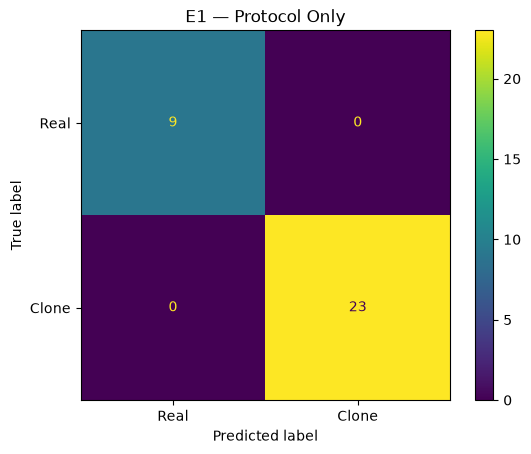

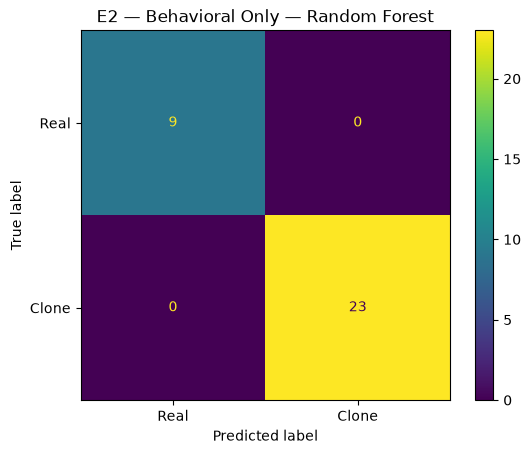

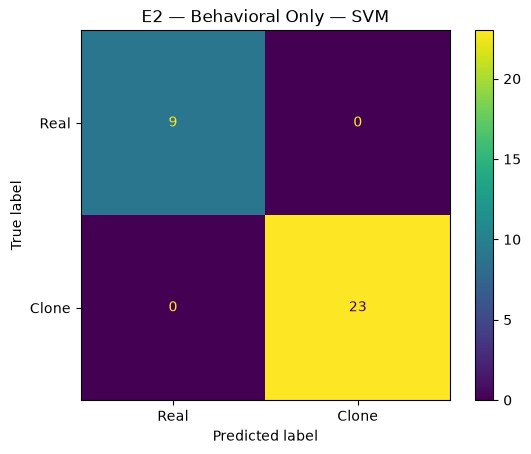

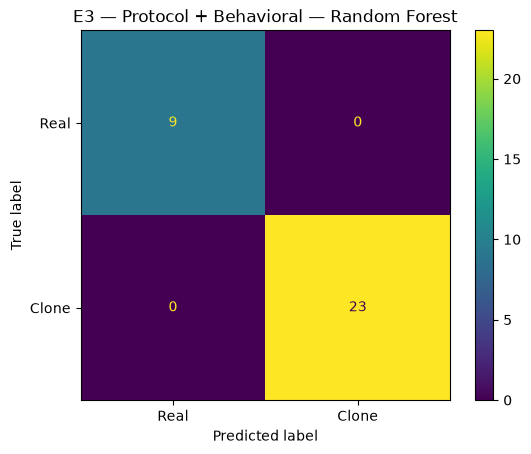

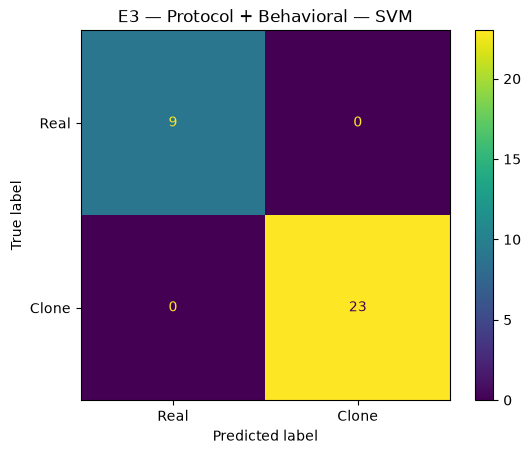

In [22]:
# ============================================================
# CELL 21 — Confusion matrices
# ============================================================

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Real", "Clone"]
    )

    disp.plot()
    plt.title(title)
    plt.show()


plot_cm(
    e1_split["y_test"],
    e1_test_pred,
    "E1 — Protocol Only"
)

for model_name, obj in e2_predictions.items():
    plot_cm(
        e2_split["y_test"],
        obj["test_pred"],
        f"E2 — Behavioral Only — {model_name}"
    )

for model_name, obj in e3_predictions.items():
    plot_cm(
        e3_split["y_test"],
        obj["test_pred"],
        f"E3 — Protocol + Behavioral — {model_name}"
    )


# Part G — Leakage / split audit

This cell explicitly verifies that no tag group appears in more than one partition.


In [23]:
# ============================================================
# CELL 22 — Group leakage audit
# ============================================================

def audit_split(split, name):
    train_groups = set(split["g_train"])
    val_groups = set(split["g_val"])
    test_groups = set(split["g_test"])

    print(f"\n{name}")
    print("Train groups:", len(train_groups))
    print("Val groups  :", len(val_groups))
    print("Test groups :", len(test_groups))

    print("Train ∩ Val :", len(train_groups & val_groups))
    print("Train ∩ Test:", len(train_groups & test_groups))
    print("Val ∩ Test  :", len(val_groups & test_groups))

    assert len(train_groups & val_groups) == 0
    assert len(train_groups & test_groups) == 0
    assert len(val_groups & test_groups) == 0

    print("PASS — no group leakage.")


audit_split(e1_split, "E1")
audit_split(e2_split, "E2")
audit_split(e3_split, "E3")



E1
Train groups: 72
Val groups  : 24
Test groups : 24
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0
PASS — no group leakage.

E2
Train groups: 72
Val groups  : 24
Test groups : 24
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0
PASS — no group leakage.

E3
Train groups: 72
Val groups  : 24
Test groups : 24
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0
PASS — no group leakage.


# Part H — S4/S5 replay evidence (supporting analysis)

S4/S5 are kept separate from the primary E1/E2/E3 Real-vs-Clone classifier.

This prevents a different 36-session replay experiment from being silently mixed into the 108-session S1/S2/S3 experiment.

They can still be reported as supporting evidence showing that replay produces a distinctive temporal/reader-success pattern.


In [24]:
# ============================================================
# CELL 23 — Replay summary
# ============================================================

s4_summary = (
    s4.groupby(["session_id", "tag_local_id"])
       .agg(
           replay_event_count=("delta_ms", "count"),
           replay_delta_mean=("delta_ms", "mean"),
           replay_delta_std=("delta_ms", "std"),
           replay_delta_median=("delta_ms", "median"),
           replay_delta_min=("delta_ms", "min"),
           replay_delta_max=("delta_ms", "max"),
       )
       .reset_index()
)

s5_summary = s5.copy()

replay_support = s4_summary.merge(
    s5_summary,
    on="session_id",
    how="left"
)

display(replay_support.head())

print("S4 sessions:", s4["session_id"].nunique())
print("S5 sessions:", s5["session_id"].nunique())


,session_id,tag_local_id,replay_event_count,replay_delta_mean,replay_delta_std,replay_delta_median,replay_delta_min,replay_delta_max,reads_A,reads_B,success_rate_pct
0,S4_TAG01_run1,TAG01,505,4.377515,2.151099,4.4760,0.502,8.832,NaN,NaN,NaN
1,S4_TAG01_run2,TAG01,506,4.308654,2.124413,4.3700,0.524,11.105,NaN,NaN,NaN
2,S4_TAG01_run3,TAG01,506,4.171393,2.185443,4.0290,0.406,11.506,NaN,NaN,NaN
3,S4_TAG02_run1,TAG02,502,4.190880,2.168240,4.0405,0.505,9.338,NaN,NaN,NaN
4,S4_TAG02_run2,TAG02,506,4.383283,2.194529,4.4105,0.540,11.528,NaN,NaN,NaN


S4 sessions: 36
S5 sessions: 36


In [25]:
# ============================================================
# CELL 24 — Save all results
# ============================================================

main_results.to_csv(
    "rfid_main_evidence_results.csv",
    index=False
)

evidence_summary.to_csv(
    "rfid_evidence_summary.csv",
    index=False
)

protocol_data.to_csv(
    "rfid_protocol_session_features.csv",
    index=False
)

behavior_data.to_csv(
    "rfid_behavior_session_features.csv",
    index=False
)

replay_support.to_csv(
    "rfid_replay_support_features.csv",
    index=False
)

print("Saved:")
for f in [
    "rfid_main_evidence_results.csv",
    "rfid_evidence_summary.csv",
    "rfid_protocol_session_features.csv",
    "rfid_behavior_session_features.csv",
    "rfid_replay_support_features.csv",
]:
    print(" -", f)


Saved:
 - rfid_main_evidence_results.csv
 - rfid_evidence_summary.csv
 - rfid_protocol_session_features.csv
 - rfid_behavior_session_features.csv
 - rfid_replay_support_features.csv


# Final interpretation template

After running the notebook, the paper/report should be written around this question:

> **Which source of security evidence helps detect RFID clones?**

Use the observed results to discuss:

1. **E1 — Protocol Only:** whether protocol/temporal evidence alone separates Clone from Real.
2. **E2 — Behavioral Only:** how much discrimination is available without protocol evidence.
3. **E3 — Protocol + Behavioral:** whether combining evidence improves held-out detection.
4. **Group-aware evaluation:** whether the effect remains when repeated sessions from the same tag are kept together.

Do **not** write a conclusion such as "Random Forest is better than SVM" unless that becomes a separate research question.

The primary conclusion should be about **evidence contribution**.


# Part I — RQ3: Detection Effectiveness vs Computational Overhead (mục 4.6)

Phần này dùng lại **đúng** các hàm và mô hình đã tạo ở trên (`group_train_val_test_split`,
`fit_univariate_protocol_detector`, `run_ml_evidence_experiment`, `e1_detector`,
`e2_predictions`, `e3_predictions`, `protocol_features_from_collision_events`).

- **Hiệu quả**: Recall và FPR trên tập test, lặp 5 seed chia dữ liệu.
- **Thời gian xử lý**: dựng vectơ đặc trưng cho **một phiên** từ các bản ghi va chạm (gọi đơn lẻ).
- **Thời gian suy luận**: một quyết định cho **một** vectơ đặc trưng (gọi đơn lẻ); kèm thời gian/mẫu khi dự đoán theo lô.
- Mọi thời gian là trung vị của nhiều lần gọi.

In [26]:
# ============================================================
# CELL 25 — RQ3 helpers + cấu hình máy
# ============================================================
import time, platform, subprocess, sklearn

def median_ms(fn, reps=200):
    fn()
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); ts.append(time.perf_counter() - t0)
    return float(np.median(ts) * 1000)

def cpu_model():
    try:
        out = subprocess.run(["lscpu"], capture_output=True, text=True).stdout
        m = re.search(r"Model name:\s*(.+)", out)
        if m:
            return re.sub(r"\s+", " ", re.sub(r"\((R|TM)\)", "", m.group(1))).strip()
    except Exception:
        pass
    return platform.processor() or platform.machine()

def recall_fpr(y, p):
    tn, fp, fn, tp = confusion_matrix(y, p, labels=[0, 1]).ravel()
    return tp / (tp + fn), fp / (fp + tn)

METHOD_LABEL = {("E2", "Random Forest"): "RF (E2)", ("E2", "SVM"): "SVM (E2)",
                ("E3", "Random Forest"): "Hybrid – RF (E3)", ("E3", "SVM"): "Hybrid – SVM (E3)"}
ORDER = ["MB/MCM (E1)", "RF (E2)", "SVM (E2)", "Hybrid – RF (E3)", "Hybrid – SVM (E3)"]

ENV = (f"{os.cpu_count()} vCPU {cpu_model()}, Python {'.'.join(platform.python_version().split('.')[:2])}, "
       f"scikit-learn {'.'.join(sklearn.__version__.split('.')[:2])}")
print("Môi trường đo:", ENV)

Môi trường đo: 4 vCPU Intel Xeon Processor @ 2.10GHz, Python 3.11, scikit-learn 1.9


In [27]:
# ============================================================
# CELL 26 — Hiệu quả phát hiện qua 5 seed (Recall, FPR)
# ============================================================
SEEDS = [42, 7, 123, 2024, 99]
eff = []
for s in SEEDS:
    sp = group_train_val_test_split(evidence_data, E1_FEATURES, seed=s)
    det = fit_univariate_protocol_detector(sp["X_train"], sp["y_train"])
    r, f = recall_fpr(sp["y_test"], predict_protocol_detector(sp["X_test"], det))
    eff.append(("MB/MCM (E1)", s, r, f, det["feature"]))
    for ev, feats in [("E2", E2_FEATURES), ("E3", E3_FEATURES)]:
        spl, _, _, preds = run_ml_evidence_experiment(evidence_data, feats, ev, seed=s)
        for mname, obj in preds.items():
            r, f = recall_fpr(spl["y_test"], obj["test_pred"])
            eff.append((METHOD_LABEL[(ev, mname)], s, r, f, ""))
eff = pd.DataFrame(eff, columns=["Method", "seed", "Recall", "FPR", "E1_feature"])
eff_summary = eff.groupby("Method").agg(Recall=("Recall", "mean"), Recall_SD=("Recall", "std"),
                                        FPR=("FPR", "mean"), FPR_SD=("FPR", "std")).reindex(ORDER)
print("E1 chọn đặc trưng:", sorted(set(eff.loc[eff.Method == "MB/MCM (E1)", "E1_feature"])))
display(eff_summary.round(3))

E1 chọn đặc trưng: ['negative_dt_ratio']


,Recall,Recall_SD,FPR,FPR_SD
Method,,,,
MB/MCM (E1),1.0,0.0,0.0,0.0
RF (E2),1.0,0.0,0.0,0.0
SVM (E2),1.0,0.0,0.0,0.0
Hybrid – RF (E3),1.0,0.0,0.0,0.0
Hybrid – SVM (E3),1.0,0.0,0.0,0.0


In [28]:
# ============================================================
# CELL 27 — Chi phí tính toán (dùng mô hình seed 42 đã huấn luyện ở Part D/E)
# ============================================================
# Thời gian xử lý: vectơ đặc trưng của MỘT phiên từ bản ghi va chạm
s2_ids = s2_coll["session_id"].unique()[:40]
s3_ids = s3_work["session_id"].unique()[:40]
proc_protocol = float(np.median(
    [median_ms(lambda g=s2_coll[s2_coll.session_id == i]: protocol_features_from_collision_events(g, "session_id", "dt"), 30) for i in s2_ids]
    + [median_ms(lambda g=s3_work[s3_work.session_id == i]: protocol_features_from_collision_events(g, "session_id", "dt_sec"), 30) for i in s3_ids]))
proc_behavior = float(np.median([median_ms(lambda g=s3[s3.session_id == i]: len(g), 200) for i in s3_ids]))
t0 = time.perf_counter(); protocol_features_from_collision_events(s2_coll, "session_id", "dt")
proc_protocol_batch = (time.perf_counter() - t0) * 1000 / s2_coll["session_id"].nunique()

cost = {}
one = e1_split["X_test"].iloc[[0]]
cost["MB/MCM (E1)"] = dict(processing=proc_protocol, inference=median_ms(lambda: predict_protocol_detector(one, e1_detector)),
                           batch=np.nan, structure="1 đặc trưng, 1 ngưỡng")
tree_nodes = []
for ev, split, preds in [("E2", e2_split, e2_predictions), ("E3", e3_split, e3_predictions)]:
    Xte = split["X_test"]; one = Xte.iloc[[0]]
    for mname, obj in preds.items():
        m = obj["model"]
        if mname == "Random Forest":
            est = m.named_steps["rf"].estimators_
            tree_nodes += [t.tree_.node_count for t in est]
            structure = f"{len(est)} cây, {sum(t.tree_.node_count for t in est)} nút"
        else:
            structure = f"{int(m.named_steps['svm'].n_support_.sum())} vectơ hỗ trợ"
        cost[METHOD_LABEL[(ev, mname)]] = dict(
            processing=proc_protocol if ev == "E3" else proc_behavior,
            inference=median_ms(lambda: m.predict(one)),
            batch=median_ms(lambda: m.predict(Xte), reps=50) / len(Xte),
            structure=structure)
cost = pd.DataFrame(cost).T.reindex(ORDER)
print(f"Xử lý đặc trưng giao thức theo lô: {proc_protocol_batch:.2f} ms/phiên")
print(f"Tỷ lệ cây RF chỉ có 3 nút: {100*np.mean(np.array(tree_nodes)==3):.1f}% | cây lớn nhất: {max(tree_nodes)} nút")
display(cost)

Xử lý đặc trưng giao thức theo lô: 0.80 ms/phiên
Tỷ lệ cây RF chỉ có 3 nút: 100.0% | cây lớn nhất: 3 nút


,processing,inference,batch,structure
MB/MCM (E1),4.341481,0.1304,NaN,"1 đặc trưng, 1 ngưỡng"
RF (E2),0.000315,17.498502,0.688043,"300 cây, 900 nút"
SVM (E2),0.000315,2.137482,0.036518,9 vectơ hỗ trợ
Hybrid – RF (E3),4.341481,16.973947,0.521533,"300 cây, 900 nút"
Hybrid – SVM (E3),4.341481,1.219131,0.036403,11 vectơ hỗ trợ


In [29]:
# ============================================================
# CELL 28 — Độ dài phiên (cửa sổ quan sát) từ các tệp va chạm
# ============================================================
def session_span_s(df, cols):
    t = pd.concat([pd.to_datetime(df[c], utc=True, format="mixed") for c in cols], axis=1)
    t["session_id"] = df["session_id"].values
    g = t.melt(id_vars="session_id").groupby("session_id")["value"]
    return float((g.max() - g.min()).dt.total_seconds().median())

span = {"S2": session_span_s(s2_coll, ["tA", "tB"]), "S3": session_span_s(s3, ["t_reader_A", "t_reader_B"])}
for k, v in span.items():
    if v <= 0:
        print(f"CẢNH BÁO: độ dài phiên {k} = {v} — timestamp trong file có thể đã bị Excel cắt mất phần giờ")
print("Trung vị độ dài phiên (giây):", {k: round(v, 1) for k, v in span.items()})

Trung vị độ dài phiên (giây): {'S2': 37.3, 'S3': 5.9}


In [30]:
# ============================================================
# CELL 29 — Bảng 4.y (dán vào bài)
# ============================================================
def fmt_proc(x):
    return "< 0.001" if x < 0.001 else f"{x:.2f}"

rows = ["| Phương pháp | Recall | FPR | Thời gian xử lý (ms/phiên) | Thời gian suy luận (ms/quyết định) | Cấu trúc mô hình |",
        "|---|---|---|---|---|---|"]
for m in ORDER:
    e, c = eff_summary.loc[m], cost.loc[m]
    inf = f"{c.inference:.2f}" + ("" if pd.isna(c.batch) else f" ({c.batch:.2f})")
    rows.append(f"| {m} | {e.Recall:.3f} | {e.FPR:.3f} | {fmt_proc(c.processing)} | {inf} | {c.structure} |")
TABLE_4Y = "\n".join(rows)
print("Môi trường đo:", ENV, "\n")
print(TABLE_4Y)
pd.concat([eff_summary, cost], axis=1).to_csv("rq3_table_4y.csv")
print("\nĐã lưu rq3_table_4y.csv")

Môi trường đo: 4 vCPU Intel Xeon Processor @ 2.10GHz, Python 3.11, scikit-learn 1.9 

| Phương pháp | Recall | FPR | Thời gian xử lý (ms/phiên) | Thời gian suy luận (ms/quyết định) | Cấu trúc mô hình |
|---|---|---|---|---|---|
| MB/MCM (E1) | 1.000 | 0.000 | 4.34 | 0.13 | 1 đặc trưng, 1 ngưỡng |
| RF (E2) | 1.000 | 0.000 | < 0.001 | 17.50 (0.69) | 300 cây, 900 nút |
| SVM (E2) | 1.000 | 0.000 | < 0.001 | 2.14 (0.04) | 9 vectơ hỗ trợ |
| Hybrid – RF (E3) | 1.000 | 0.000 | 4.34 | 16.97 (0.52) | 300 cây, 900 nút |
| Hybrid – SVM (E3) | 1.000 | 0.000 | 4.34 | 1.22 (0.04) | 11 vectơ hỗ trợ |

Đã lưu rq3_table_4y.csv


# Part J — Bảng 7 (bản sửa): mean ± SD, thời gian huấn luyện, kích thước mô hình

Part J thay cho Cell 27 và 29 khi lập Bảng 7. Mọi phép đo dưới đây chạy trong **một lần chạy, trên cùng một máy**:

- **Recall, FPR**: trung bình ± SD trên tập test qua 5 seed chia dữ liệu.
- **Processing (ms/session)**: dựng vectơ đặc trưng của một phiên từ bản ghi va chạm. Mỗi phiên lấy trung vị của 30 lần gọi; báo mean ± SD trên toàn bộ phiên.
- **Training (ms)**: một lần `fit` trên tập train (không tính GroupKFold CV); mean ± SD qua 5 seed.
- **Inference (ms/decision)**: một quyết định cho một vectơ đặc trưng; mỗi seed lấy trung vị của 200 lần gọi; mean ± SD qua 5 seed.
- **Model size (KB)**: kích thước mô hình sau khi tuần tự hoá bằng `pickle`; mean ± SD qua 5 seed.

Lưu ý: con số trong ngoặc ở Cell 29, ví dụ `23.04 (0.49)`, **không phải SD** mà là thời gian/mẫu khi dự đoán theo lô. Part J tách riêng đại lượng này.

In [31]:
# ============================================================
# CELL 30 — RQ3 (bản sửa): mọi phép đo trong cùng một lần chạy
# ============================================================
import pickle, time, platform

SEEDS = [42, 7, 123, 2024, 99]

def calls_ms(fn, reps):
    fn()                                   # warm-up
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); ts.append(time.perf_counter() - t0)
    return float(np.median(ts) * 1000)

def once_ms(fn):
    t0 = time.perf_counter(); fn(); return (time.perf_counter() - t0) * 1000

def size_kb(obj):
    return len(pickle.dumps(obj)) / 1024

# --- Processing: mỗi phiên = trung vị 30 lần gọi; tổng hợp trên mọi phiên ---
proc_protocol = np.array(
    [calls_ms(lambda g=g: protocol_features_from_collision_events(g, "session_id", "dt"), 30)
     for _, g in s2_coll.groupby("session_id")]
    + [calls_ms(lambda g=g: protocol_features_from_collision_events(g, "session_id", "dt_sec"), 30)
       for _, g in s3_work.groupby("session_id")])
proc_behavior = np.array([calls_ms(lambda g=g: len(g), 200) for _, g in s3.groupby("session_id")])

# --- Hiệu quả, huấn luyện, suy luận, kích thước: 5 seed ---
rows = []
for s in SEEDS:
    sp = group_train_val_test_split(evidence_data, E1_FEATURES, seed=s)
    t = once_ms(lambda: fit_univariate_protocol_detector(sp["X_train"], sp["y_train"]))
    det = fit_univariate_protocol_detector(sp["X_train"], sp["y_train"])
    r, f = recall_fpr(sp["y_test"], predict_protocol_detector(sp["X_test"], det))
    one = sp["X_test"].iloc[[0]]
    rows.append(dict(Method="MB/MCM (E1)", seed=s, Recall=r, FPR=f, train_ms=t,
                     infer_ms=calls_ms(lambda: predict_protocol_detector(one, det), 200), batch_ms=np.nan,
                     size_kb=size_kb({k: det[k] for k in ("feature", "threshold", "real_is_low")}),
                     n_struct=1, unit="threshold"))
    for ev, feats in [("E2", E2_FEATURES), ("E3", E3_FEATURES)]:
        sp = group_train_val_test_split(evidence_data, feats, seed=s)
        one, Xte = sp["X_test"].iloc[[0]], sp["X_test"]
        for mname, make in [("Random Forest", make_rf), ("SVM", make_svm)]:
            m = make()
            t = once_ms(lambda: m.fit(sp["X_train"], sp["y_train"]))
            r, f = recall_fpr(sp["y_test"], m.predict(Xte))
            if mname == "Random Forest":
                n_struct, unit = sum(e.tree_.node_count for e in m.named_steps["rf"].estimators_), "nodes"
            else:
                n_struct, unit = int(m.named_steps["svm"].n_support_.sum()), "support vectors"
            rows.append(dict(Method=METHOD_LABEL[(ev, mname)], seed=s, Recall=r, FPR=f, train_ms=t,
                             infer_ms=calls_ms(lambda: m.predict(one), 200),
                             batch_ms=calls_ms(lambda: m.predict(Xte), 50) / len(Xte),
                             size_kb=size_kb(m), n_struct=n_struct, unit=unit))
rq3_runs = pd.DataFrame(rows)

# --- Bảng 7 ---
def pm(x, d=2):
    x = np.asarray(x, float)
    return f"{x.mean():.{d}f} ± {x.std(ddof=1):.{d}f}"

def pm_rate(x):
    x = np.asarray(x, float)
    return f"{x.mean():.3f}" if x.std() == 0 else pm(x, 3)

PROC = {"MB/MCM (E1)": proc_protocol, "RF (E2)": proc_behavior, "SVM (E2)": proc_behavior,
        "Hybrid – RF (E3)": proc_protocol, "Hybrid – SVM (E3)": proc_protocol}

lines = ["| Method | Recall | FPR | Processing (ms/session) | Training (ms) | Inference (ms/decision) | Model size (KB) |",
         "|---|---|---|---|---|---|---|"]
summary = []
for m in ORDER:
    g = rq3_runs[rq3_runs.Method == m]
    p = PROC[m]
    proc_txt = "< 0.001" if p.mean() < 0.001 else pm(p)
    lines.append(f"| {m} | {pm_rate(g.Recall)} | {pm_rate(g.FPR)} | {proc_txt} | {pm(g.train_ms)} | "
                 f"{pm(g.infer_ms)} | {pm(g.size_kb)} |")
    summary.append(dict(Method=m, Recall=g.Recall.mean(), Recall_SD=g.Recall.std(), FPR=g.FPR.mean(), FPR_SD=g.FPR.std(),
                        processing_ms=p.mean(), processing_SD=p.std(ddof=1),
                        training_ms=g.train_ms.mean(), training_SD=g.train_ms.std(),
                        inference_ms=g.infer_ms.mean(), inference_SD=g.infer_ms.std(),
                        batch_ms_per_sample=g.batch_ms.mean(), size_kb=g.size_kb.mean(), size_SD=g.size_kb.std(),
                        structure=f"{g.n_struct.min()}–{g.n_struct.max()} {g.unit.iloc[0]}"))
TABLE_7 = "\n".join(lines)
rq3_summary = pd.DataFrame(summary).set_index("Method")

ENV = f"{os.cpu_count()} vCPU {cpu_model()}, Python {platform.python_version()}, scikit-learn {sklearn.__version__}"
print("Môi trường đo:", ENV)
print(f"Processing: {len(proc_protocol)} phiên (giao thức), {len(proc_behavior)} phiên (hành vi)\n")
print(TABLE_7)
print("\nCấu trúc mô hình và thời gian/mẫu khi dự đoán theo lô:")
display(rq3_summary[["structure", "batch_ms_per_sample"]].round(3))
rq3_runs.to_csv("rq3_table7_runs.csv", index=False)
rq3_summary.to_csv("rq3_table7_summary.csv")
print("Đã lưu rq3_table7_runs.csv, rq3_table7_summary.csv")

Môi trường đo: 4 vCPU Intel Xeon Processor @ 2.10GHz, Python 3.11.15, scikit-learn 1.9.1
Processing: 216 phiên (giao thức), 108 phiên (hành vi)

| Method | Recall | FPR | Processing (ms/session) | Training (ms) | Inference (ms/decision) | Model size (KB) |
|---|---|---|---|---|---|---|
| MB/MCM (E1) | 1.000 | 0.000 | 4.43 ± 0.71 | 8.95 ± 2.42 | 0.12 ± 0.03 | 0.22 ± 0.00 |
| RF (E2) | 1.000 | 0.000 | < 0.001 | 322.36 ± 14.71 | 17.25 ± 0.69 | 160.54 ± 0.09 |
| SVM (E2) | 1.000 | 0.000 | < 0.001 | 6.05 ± 1.53 | 1.31 ± 0.39 | 2.21 ± 0.02 |
| Hybrid – RF (E3) | 1.000 | 0.000 | 4.43 ± 0.71 | 343.09 ± 48.43 | 17.47 ± 1.68 | 160.83 ± 0.09 |
| Hybrid – SVM (E3) | 1.000 | 0.000 | 4.43 ± 0.71 | 7.03 ± 1.95 | 1.32 ± 0.17 | 3.99 ± 0.32 |

Cấu trúc mô hình và thời gian/mẫu khi dự đoán theo lô:


,structure,batch_ms_per_sample
Method,,
MB/MCM (E1),1–1 threshold,NaN
RF (E2),900–900 nodes,0.449
SVM (E2),8–10 support vectors,0.031
Hybrid – RF (E3),900–900 nodes,0.488
Hybrid – SVM (E3),7–13 support vectors,0.040


Đã lưu rq3_table7_runs.csv, rq3_table7_summary.csv
